In [5]:
df_clean.to_csv("../data/processed/on_time_q1_2024_final.csv", index=False)

print("file saved")

file saved


In [4]:
df_clean["month"] = pd.to_datetime(df_clean["FL_DATE"]).dt.month

print("month column created")

month column created


/var/folders/qb/9bsn8dl942bbdrp67pvjggd40000gn/T/ipykernel_20113/1437026226.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["month"] = pd.to_datetime(df_clean["FL_DATE"]).dt.month


In [3]:
conditions = [
    df_clean["DEP_DELAY"] < 0,
    (df_clean["DEP_DELAY"] >= 0) & (df_clean["DEP_DELAY"] <= 15),
    (df_clean["DEP_DELAY"] > 15) & (df_clean["DEP_DELAY"] <= 60),
    (df_clean["DEP_DELAY"] > 60) & (df_clean["DEP_DELAY"] <= 180),
    df_clean["DEP_DELAY"] > 180
]

choices = ["Early", "On Time", "Minor Delay", "Moderate Delay", "Severe Delay"]

df_clean["delay_category"] = np.select(conditions, choices, default="Unknown")

print("delay_category created")

delay_category created


In [2]:
df_clean = pd.read_csv("../data/processed/on_time_q1_2024_cleaned.csv")

print(df_clean.shape)

(1654563, 10)


In [1]:
import pandas as pd
import numpy as np

## Business Recommendations

Based on the analysis, the following recommendations can help improve operational performance and reduce potential revenue leakage:

1. **Prioritize high-risk routes**
   Routes identified with high delay and cancellation rates should be prioritized for operational intervention.

2. **Focus on reducing cancellations**
   Since cancellation rate is strongly associated with departure delay, improving cancellation management can significantly enhance overall performance.

3. **Investigate high-delay routes**
   Routes with consistently high average delays should be analyzed further for root causes such as airport congestion, scheduling inefficiencies, or resource constraints.

4. **Incorporate additional data sources**
   To better understand and predict delays, future analysis should include factors such as weather conditions, carrier-specific data, and time-of-day patterns.

5. **Develop route-level monitoring**
   A route-level risk scoring framework can be used as an early warning system to identify operational inefficiencies and take proactive action.

## Final Modeling Summary

The regression analysis shows that:

- Cancellation rate is the strongest predictor of route-level departure delay
- Route distance has a small but positive contribution
- Flight volume has minimal impact on delay in this model

While adding route distance improved model performance, the overall explanatory power remains low (R² ≈ 0.07), indicating that departure delay is influenced by additional factors not included in this dataset.

These may include:
- airline-specific operational practices
- airport congestion levels
- weather conditions
- time-of-day and scheduling effects

Overall, the modeling results highlight that operational inefficiency is a multi-factor problem and cannot be fully explained using a small set of variables.

In [89]:
model_comparison = pd.DataFrame({
    "Model": ["Revised Model", "Expanded Model"],
    "MAE": [mae2, mae3],
    "RMSE": [rmse2, rmse3],
    "R_squared": [r2_2, r2_3]
})

model_comparison

,Model,MAE,RMSE,R_squared
0,Revised Model,4.410655,5.447372,0.034745
1,Expanded Model,4.355160,5.346294,0.070234


## Model Comparison

To compare the regression approaches, I summarize the evaluation metrics of the revised model and the expanded model in a single table.

This helps show whether adding route distance improved predictive performance.

### Interpretation of Expanded Model Performance

Adding average route distance improved model performance modestly. The R² increased from approximately 0.035 to 0.070, indicating that the expanded feature set explains more variation in route-level average departure delay than the earlier model.

However, the overall explanatory power remains limited, suggesting that departure delay is influenced by additional factors not yet included in the model. These may include carrier effects, seasonality, airport congestion, weather conditions, and time-of-day patterns.

From a business perspective, this result shows that cancellation behavior and route distance are relevant predictors of delay, but they are not sufficient on their own to fully explain operational disruption.

In [88]:
y3_pred = model3.predict(X3_test)

mae3 = mean_absolute_error(y3_test, y3_pred)
rmse3 = np.sqrt(mean_squared_error(y3_test, y3_pred))
r2_3 = r2_score(y3_test, y3_pred)

print("MAE:", mae3)
print("RMSE:", rmse3)
print("R-squared:", r2_3)

MAE: 4.355160440860835
RMSE: 5.346294136855792
R-squared: 0.07023421336441871


### Evaluating the Expanded Model

After fitting the expanded regression model, I evaluate its performance on the test set using MAE, RMSE, and R².

This helps determine whether adding route distance improves the ability to explain average departure delay.

In [87]:
coefficients3 = pd.DataFrame({
    "Feature": X3.columns,
    "Coefficient": model3.coef_
})

coefficients3

,Feature,Coefficient
0,cancel_rate,46.281823
1,flight_count,0.001305
2,avg_distance,0.002362


In [86]:
model3 = LinearRegression()
model3.fit(X3_train, y3_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Fitting the Expanded Linear Regression Model

I now fit an updated linear regression model to predict route-level average departure delay using cancellation rate, flight count, and average route distance.

This helps evaluate whether adding route distance improves the model’s explanatory power.

In [85]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

X3_train.shape, X3_test.shape, y3_train.shape, y3_test.shape

((792, 3), (198, 3), (792,), (198,))

### Train-Test Split for the Expanded Model

I split the expanded modeling dataset into training and test sets before fitting the updated regression model.

In [84]:
model_df2 = route_summary[[
    "ROUTE",
    "avg_dep_delay",
    "cancel_rate",
    "flight_count",
    "avg_distance"
]].copy()

X3 = model_df2[["cancel_rate", "flight_count", "avg_distance"]]
y3 = model_df2["avg_dep_delay"]

X3.head(), y3.head()

(   cancel_rate  flight_count  avg_distance
 0     0.027778           612         349.0
 1     0.013060           536         569.0
 2     0.000000           522         677.0
 3     0.002809           712         328.0
 4     0.000000           520         143.0,
 0     7.142157
 1    25.641791
 2     4.576628
 3     9.512640
 4    21.115385
 Name: avg_dep_delay, dtype: float64)

### Updating the Modeling Dataset

I update the revised modeling dataset to include route-level average distance as an additional predictor of average departure delay.

In [83]:
route_distance = (
    df_filtered.groupby("ROUTE")["DISTANCE"]
    .mean()
    .reset_index()
    .rename(columns={"DISTANCE": "avg_distance"})
)

route_summary = route_summary.merge(route_distance, on="ROUTE", how="left")

route_summary.head()

,ROUTE,avg_dep_delay,cancel_rate,flight_count,delay_z,cancel_z,risk_score,risk_group,avg_distance
0,ABQ-DEN,7.142157,0.027778,612,-0.846103,0.897051,0.025474,High Risk,349.0
1,ABQ-DFW,25.641791,0.013060,536,2.515385,-0.230817,1.142284,High Risk,569.0
2,ABQ-LAX,4.576628,0.000000,522,-1.312274,-1.231602,-1.271938,Low Risk,677.0
3,ABQ-PHX,9.512640,0.002809,712,-0.415373,-1.016345,-0.715859,Low Risk,328.0
4,AGS-ATL,21.115385,0.000000,520,1.692911,-1.231602,0.230655,High Risk,143.0


### Expanding the Feature Set

To improve the regression model, I add route-level average distance as an additional feature.

Distance may help explain delay patterns because longer routes can behave differently operationally than shorter routes.

### Interpretation of Revised Model Performance

The revised linear regression model produced an R² of approximately 0.035, indicating that cancellation rate and flight count explain only a small portion of the variation in route-level average departure delay.

This suggests that while cancellation behavior is positively associated with delay, average departure delay is influenced by additional factors not yet included in the model, such as route distance, airport congestion, seasonality, weather, and carrier-specific operational patterns.

From a business perspective, this result is still useful because it shows that simple operational indicators alone are not sufficient to fully explain delay performance, reinforcing the need for a richer feature set.

In [82]:
y2_pred = model2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print("MAE:", mae2)
print("RMSE:", rmse2)
print("R-squared:", r2_2)

MAE: 4.410654892468743
RMSE: 5.447371716337694
R-squared: 0.03474538463027066


### Evaluating the Revised Model

After fitting the revised linear regression model, I generate predictions on the test set and evaluate performance using MAE, RMSE, and R².

This helps assess how well cancellation rate and flight volume explain route-level average departure delay.

In [81]:
coefficients2 = pd.DataFrame({
    "Feature": X2.columns,
    "Coefficient": model2.coef_
})

coefficients2

,Feature,Coefficient
0,cancel_rate,55.950401
1,flight_count,0.001198


In [80]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Fitting the Revised Linear Regression Model

I now fit a revised linear regression model to predict route-level average departure delay using cancellation rate and flight count.

This model is more appropriate because it avoids target leakage and focuses on explaining a directly observed operational outcome.

In [79]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape

((792, 2), (198, 2), (792,), (198,))

### Train-Test Split for the Revised Model

I split the revised modeling dataset into training and test sets so that I can evaluate the model on unseen routes.

In [78]:
X2 = model_df[["cancel_rate", "flight_count"]]
y2 = model_df["avg_dep_delay"]

X2.head(), y2.head()

(   cancel_rate  flight_count
 0     0.027778           612
 1     0.013060           536
 2     0.000000           522
 3     0.002809           712
 4     0.000000           520,
 0     7.142157
 1    25.641791
 2     4.576628
 3     9.512640
 4    21.115385
 Name: avg_dep_delay, dtype: float64)

### Defining Features and Target for the Revised Model

For the revised regression model:

- The target variable is `avg_dep_delay`
- The features are `cancel_rate` and `flight_count`

This setup is more appropriate because the target is no longer directly constructed from the input variables.

### Revised Modeling Objective

To avoid target leakage, I redefine the modeling objective.

Instead of predicting a derived risk score, I use `avg_dep_delay` as the target variable and evaluate whether route-level cancellation rate and flight volume help explain route-level departure delay behavior.

### Important Modeling Note: Target Leakage

The linear regression model achieved near-perfect performance, with an R² of 1.0 and almost zero error. However, this result is not evidence of a truly predictive model.

This happened because the target variable, `risk_score`, was directly constructed using `avg_dep_delay` and `cancel_rate`, which were also included as input features. As a result, the model is effectively reconstructing the target rather than learning an independent relationship.

This is a form of target leakage and indicates that the model, while mathematically correct, is not suitable as a final predictive model. A more meaningful next step would be to model a business-relevant outcome that is not directly derived from the same input features.

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 1.88051419273733e-12
RMSE: 2.3137118474196352e-12
R-squared: 1.0


### Model Evaluation

To evaluate the linear regression model, I calculate standard regression metrics:

- **MAE (Mean Absolute Error)**: average absolute prediction error
- **RMSE (Root Mean Squared Error)**: penalizes larger errors more strongly
- **R²**: proportion of variance explained by the model

These metrics help assess how well the model predicts route-level risk.

In [76]:
y_pred = model.predict(X_test)

y_pred[:5]

array([ 0.1285012 ,  0.76165935, -0.6192398 ,  1.17427072, -0.96400193])

### Generating Predictions

After training the linear regression model, I generate predictions on the test set. These predictions will be used to evaluate how well the model captures route-level operational risk.

In [75]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,avg_dep_delay,9.085281e-02
1,cancel_rate,3.831576e+01
2,flight_count,-2.838036e-15


### Model Coefficients

The coefficients of the linear regression model help interpret how each feature contributes to the risk score.

Positive coefficients indicate that an increase in the feature increases risk, while negative coefficients indicate the opposite.

In [74]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Linear Regression Model

I begin with a simple linear regression model to understand the relationship between route-level features and the overall risk score.

This model helps quantify how factors like delay, cancellation rate, and flight volume contribute to operational risk.

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((792, 3), (198, 3), (792,), (198,))

In [72]:
%pip install scikit-learn

75449.03s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Train-Test Split

Before fitting the regression model, I split the route-level dataset into training and test sets.

This helps evaluate how well the model generalizes to unseen data rather than only fitting the routes used for training.

In [69]:
X = model_df[["avg_dep_delay", "cancel_rate", "flight_count"]]
y = model_df["risk_score"]

X.head(), y.head()

(   avg_dep_delay  cancel_rate  flight_count
 0       7.142157     0.027778           612
 1      25.641791     0.013060           536
 2       4.576628     0.000000           522
 3       9.512640     0.002809           712
 4      21.115385     0.000000           520,
 0    0.025474
 1    1.142284
 2   -1.271938
 3   -0.715859
 4    0.230655
 Name: risk_score, dtype: float64)

### Separating Features and Target

To prepare for regression modeling, I separate the independent variables (features) from the dependent variable (target).

- The target variable is `risk_score`
- The features are `avg_dep_delay`, `cancel_rate`, and `flight_count`

### Defining the First Modeling Objective

For the first regression model, I use `risk_score` as the target variable.

This allows me to model route-level operational risk using available route features such as average departure delay, cancellation rate, and flight count. The goal of this model is not final revenue prediction yet, but to establish an interpretable operational risk framework before integrating fare and traffic data.

In [68]:
model_df = route_summary[[
    "ROUTE",
    "avg_dep_delay",
    "cancel_rate",
    "flight_count",
    "risk_score"
]].copy()

model_df.head()

,ROUTE,avg_dep_delay,cancel_rate,flight_count,risk_score
0,ABQ-DEN,7.142157,0.027778,612,0.025474
1,ABQ-DFW,25.641791,0.013060,536,1.142284
2,ABQ-LAX,4.576628,0.000000,522,-1.271938
3,ABQ-PHX,9.512640,0.002809,712,-0.715859
4,AGS-ATL,21.115385,0.000000,520,0.230655


## Preparing Data for Regression Modeling

To support route-level modeling, I create a dataset where each row represents a route and each column represents an operational feature.

This modeling table will be used to understand which variables are most strongly associated with route-level operational risk.

### Interpretation of Hypothesis Test 2

The Mann-Whitney U test returned a p-value far below 0.05, indicating a statistically significant difference in cancellation rate between high-risk and low-risk routes.

Therefore, I reject the null hypothesis and conclude that high-risk routes have meaningfully different cancellation behavior compared to low-risk routes.

In business terms, this strengthens the route risk framework by showing that the identified high-risk routes are associated not only with higher delays, but also with significantly worse cancellation performance.

In [67]:
u_stat_cancel, p_value_cancel = mannwhitneyu(high_risk_cancel, low_risk_cancel)

print("U-statistic:", u_stat_cancel)
print("p-value:", p_value_cancel)

U-statistic: 204488.5
p-value: 3.327948673209923e-74


### Hypothesis Test 2: Mann-Whitney U Test for Cancellation Rate

Because the normality assumption is violated for both route groups, I use the Mann-Whitney U test to compare cancellation rates between high-risk and low-risk routes.

This test helps determine whether route risk grouping is associated with significantly different cancellation behavior.

In [66]:
sample_size_high_cancel = min(len(high_risk_cancel), 500)
sample_size_low_cancel = min(len(low_risk_cancel), 500)

shapiro_high_cancel = shapiro(high_risk_cancel.sample(sample_size_high_cancel, random_state=42))
shapiro_low_cancel = shapiro(low_risk_cancel.sample(sample_size_low_cancel, random_state=42))

print("High Risk cancellation p-value:", shapiro_high_cancel.pvalue)
print("Low Risk cancellation p-value:", shapiro_low_cancel.pvalue)

High Risk cancellation p-value: 2.838623647666221e-18
Low Risk cancellation p-value: 3.3821243968846102e-15


### Assumption Check for Hypothesis 2: Normality of Cancellation Rate

Before selecting the appropriate statistical test, I check whether cancellation rates are approximately normally distributed within the high-risk and low-risk route groups.

If normality is violated, I will again use a non-parametric test.

In [65]:
high_risk_cancel = route_summary[route_summary["risk_group"] == "High Risk"]["cancel_rate"]
low_risk_cancel = route_summary[route_summary["risk_group"] == "Low Risk"]["cancel_rate"]

high_risk_cancel.head(), low_risk_cancel.head()

(0    0.027778
 1    0.013060
 4    0.000000
 5    0.025271
 6    0.030739
 Name: cancel_rate, dtype: float64,
 2     0.000000
 3     0.002809
 8     0.001923
 9     0.001073
 10    0.001934
 Name: cancel_rate, dtype: float64)

### Hypothesis 2: Do high-risk routes have higher cancellation rates than low-risk routes?

- **Null Hypothesis (H0):** There is no significant difference in cancellation rate between high-risk and low-risk routes.
- **Alternative Hypothesis (H1):** High-risk routes have a significantly different cancellation rate than low-risk routes.

This test helps validate whether the route risk grouping is also associated with meaningful differences in service instability.

### Interpretation of Hypothesis Test 1

The Mann-Whitney U test returned a p-value far below 0.05, indicating a statistically significant difference in average departure delay between high-risk and low-risk routes.

Therefore, I reject the null hypothesis and conclude that route risk grouping is associated with meaningful differences in operational performance.

In business terms, this suggests that the routes identified as high-risk are not only theoretically riskier based on combined metrics, but also demonstrate significantly worse departure delay behavior in practice.

In [64]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(high_risk_delay, low_risk_delay)

print("U-statistic:", u_stat)
print("p-value:", p_value)

U-statistic: 214897.0
p-value: 9.977209404696818e-94


### Hypothesis Test: Mann-Whitney U Test

Since the normality assumption is violated for both groups, I use the Mann-Whitney U test, a non-parametric alternative to the t-test.

This test evaluates whether the distribution of average departure delay differs significantly between high-risk and low-risk routes.

In [63]:
print("High Risk p-value:", shapiro_high.pvalue)
print("Low Risk p-value:", shapiro_low.pvalue)

High Risk p-value: 9.062581533343623e-06
Low Risk p-value: 0.03723775816400981


In [62]:
from scipy.stats import shapiro

sample_size_high = min(len(high_risk_delay), 500)
sample_size_low = min(len(low_risk_delay), 500)

shapiro_high = shapiro(high_risk_delay.sample(sample_size_high, random_state=42))
shapiro_low = shapiro(low_risk_delay.sample(sample_size_low, random_state=42))

shapiro_high, shapiro_low

(ShapiroResult(statistic=np.float64(0.982138323614052), pvalue=np.float64(9.062581533343623e-06)),
 ShapiroResult(statistic=np.float64(0.9936979192766868), pvalue=np.float64(0.03723775816400981)))

In [60]:
%pip install scipy

70998.13s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 5.2 MB/s  0:00:03m0:00:0100:01

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Assumption Check: Normality Test

To support test selection, I run the Shapiro-Wilk test on route-level average departure delay for both risk groups.

- If the p-value is less than 0.05, I reject normality.
- If normality is violated, I will use a non-parametric test such as the Mann-Whitney U test.

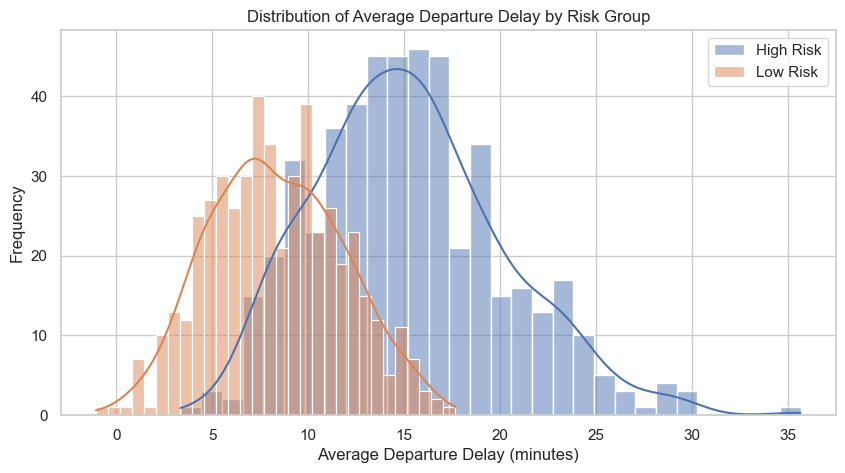

In [58]:
plt.figure(figsize=(10, 5))
sns.histplot(high_risk_delay, bins=30, kde=True, label="High Risk", alpha=0.5)
sns.histplot(low_risk_delay, bins=30, kde=True, label="Low Risk", alpha=0.5)

plt.title("Distribution of Average Departure Delay by Risk Group")
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Assumption Check: Distribution of Route-Level Average Departure Delay

Before choosing a statistical test, I inspect the distribution of average departure delay for high-risk and low-risk routes.

If the distributions are strongly non-normal, a non-parametric test may be more appropriate than a standard t-test.

In [57]:
high_risk_delay = route_summary[route_summary["risk_group"] == "High Risk"]["avg_dep_delay"]
low_risk_delay = route_summary[route_summary["risk_group"] == "Low Risk"]["avg_dep_delay"]

high_risk_delay.head(), low_risk_delay.head()

(0     7.142157
 1    25.641791
 4    21.115385
 5     7.929603
 6     8.776978
 Name: avg_dep_delay, dtype: float64,
 2      4.576628
 3      9.512640
 8     12.105769
 9      6.420601
 10     4.353965
 Name: avg_dep_delay, dtype: float64)

## Hypothesis Testing

### Hypothesis 1: Do high-risk routes have higher average departure delay than low-risk routes?

- **Null Hypothesis (H0):** There is no significant difference in average departure delay between high-risk and low-risk routes.
- **Alternative Hypothesis (H1):** High-risk routes have a significantly different average departure delay than low-risk routes.

This test helps validate whether the route risk grouping corresponds to a meaningful operational difference.

## EDA Summary

The exploratory analysis shows that airline delays are highly right-skewed, with most flights operating close to schedule but a smaller number experiencing very large delays.

At the route level, operational performance is not evenly distributed. Some high-volume routes consistently show higher average departure delays, while others also exhibit elevated cancellation rates.

By combining delay and cancellation behavior into a route risk score, I identified a set of higher-risk routes that appear more operationally unstable than the rest of the network. Boxplot comparisons further show that these high-risk routes have meaningfully higher delay and cancellation patterns than low-risk routes.

These findings motivate the next step of the analysis: statistically testing whether these differences are significant.

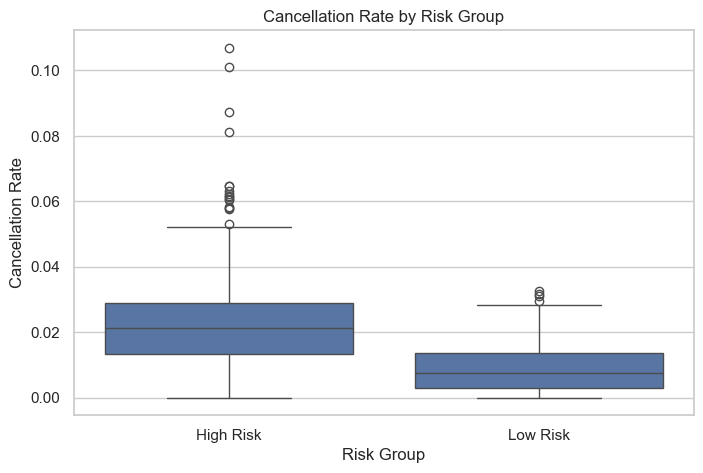

In [56]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=route_summary, x="risk_group", y="cancel_rate")
plt.title("Cancellation Rate by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Cancellation Rate")
plt.show()

### Comparing Cancellation Rate Across Risk Groups

To further validate the route risk grouping, I compare cancellation rates across high-risk and low-risk routes.

If the grouping is meaningful, high-risk routes should also show higher cancellation rates on average.

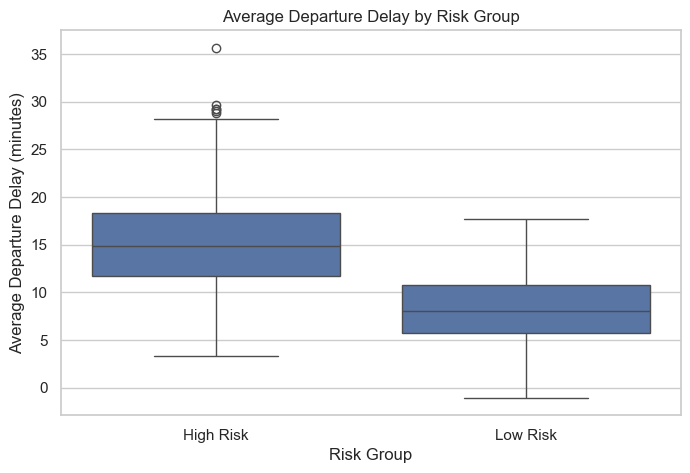

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=route_summary, x="risk_group", y="avg_dep_delay")
plt.title("Average Departure Delay by Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Average Departure Delay (minutes)")
plt.show()

### Comparing Departure Delay Across Risk Groups

To validate whether the route risk grouping is meaningful, I compare average departure delay across high-risk and low-risk routes.

In [54]:
route_summary["risk_group"] = "Low Risk"
route_summary.loc[
    route_summary["risk_score"] >= route_summary["risk_score"].median(),
    "risk_group"
] = "High Risk"

route_summary["risk_group"].value_counts()

risk_group
High Risk    495
Low Risk     495
Name: count, dtype: int64

### Creating High-Risk and Low-Risk Route Groups

To support later statistical testing, I divide routes into risk groups based on the route risk score.

This makes it possible to compare operational performance across more and less risky route segments.

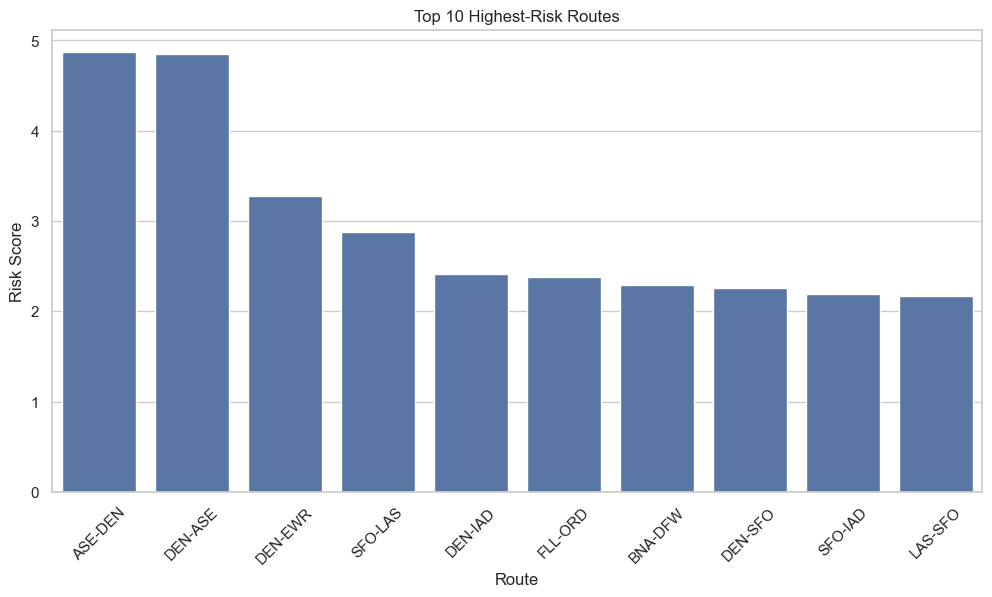

In [53]:
top_risk_routes = route_summary.sort_values("risk_score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_risk_routes, x="ROUTE", y="risk_score")
plt.title("Top 10 Highest-Risk Routes")
plt.xlabel("Route")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()

### Visualizing the Highest-Risk Routes

To make the route-level operational risk easier to interpret, I visualize the top 10 routes with the highest combined risk score.

These routes represent airport pairs with relatively high average departure delays and higher cancellation rates compared to the rest of the network.

In [52]:
route_summary["delay_z"] = (
    route_summary["avg_dep_delay"] - route_summary["avg_dep_delay"].mean()
) / route_summary["avg_dep_delay"].std()

route_summary["cancel_z"] = (
    route_summary["cancel_rate"] - route_summary["cancel_rate"].mean()
) / route_summary["cancel_rate"].std()

route_summary["risk_score"] = (
    route_summary["delay_z"] + route_summary["cancel_z"]
) / 2

route_summary.sort_values("risk_score", ascending=False).head(10)

,ROUTE,avg_dep_delay,cancel_rate,flight_count,delay_z,cancel_z,risk_score
7,ASE-DEN,27.135593,0.106910,767,2.786817,6.961076,4.873946
242,DEN-ASE,29.277267,0.101183,761,3.175971,6.522178,4.849074
256,DEN-EWR,17.823620,0.087423,652,1.094779,5.467779,3.281279
898,SFO-LAS,28.240584,0.052267,1301,2.987600,2.773735,2.880667
258,DEN-IAD,18.814540,0.062315,674,1.274835,3.543656,2.409245
402,FLL-ORD,28.853982,0.037611,904,3.099058,1.650557,2.374807
98,BNA-DFW,29.025271,0.034898,831,3.130182,1.442663,2.286422
282,DEN-SFO,29.254918,0.033607,1220,3.171910,1.343720,2.257815
895,SFO-IAD,18.331407,0.057803,519,1.187047,3.197965,2.192506
509,LAS-SFO,23.279661,0.045455,1298,2.086172,2.251649,2.168911


### Creating a Simple Route Risk Score

To create a more interpretable route-level view, I combine average departure delay and cancellation rate into a simple operational risk score.

Since these two variables are measured on different scales, I first standardize them and then average the standardized values to create a combined score.

In [51]:
route_summary.sort_values(
    by=["avg_dep_delay", "cancel_rate"],
    ascending=False
).head(10)

,ROUTE,avg_dep_delay,cancel_rate,flight_count
89,BDL-MCO,35.666667,0.013889,504
892,SFO-DFW,29.607261,0.011001,909
242,DEN-ASE,29.277267,0.101183,761
282,DEN-SFO,29.254918,0.033607,1220
98,BNA-DFW,29.025271,0.034898,831
402,FLL-ORD,28.853982,0.037611,904
898,SFO-LAS,28.240584,0.052267,1301
798,PHX-SFO,28.193412,0.019426,1184
7,ASE-DEN,27.135593,0.106910,767
649,MIA-TPA,26.549921,0.014263,631


### Identifying High-Risk Routes

To identify operationally risky routes, I sort the route summary table by average departure delay and cancellation rate. This helps surface routes that may require closer operational attention.

In [50]:
route_summary = df_filtered.groupby("ROUTE").agg(
    avg_dep_delay=("DEP_DELAY", "mean"),
    cancel_rate=("CANCELLED", "mean"),
    flight_count=("ROUTE", "count")
).reset_index()

route_summary.head()

,ROUTE,avg_dep_delay,cancel_rate,flight_count
0,ABQ-DEN,7.142157,0.027778,612
1,ABQ-DFW,25.641791,0.013060,536
2,ABQ-LAX,4.576628,0.000000,522
3,ABQ-PHX,9.512640,0.002809,712
4,AGS-ATL,21.115385,0.000000,520


### Creating a Route Risk Summary Table

To move from individual metrics to a more business-oriented view, I combine route-level average departure delay and cancellation rate into a single summary table.

This helps identify routes that are operationally risky across multiple dimensions, rather than evaluating each metric in isolation.

In [49]:
route_cancel_rate = (
    df_filtered.groupby("ROUTE")["CANCELLED"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

route_cancel_rate

ROUTE
ASE-DEN    0.106910
DEN-ASE    0.101183
DEN-EWR    0.087423
EWR-DEN    0.081040
PBI-EWR    0.064833
EWR-PBI    0.064769
RSW-EWR    0.063123
DEN-IAD    0.062315
LGA-MDW    0.061489
EWR-RSW    0.061462
Name: CANCELLED, dtype: float64

### Route-Level Cancellation Rate

In addition to delays, cancellations are an important indicator of operational disruption. I calculate the cancellation rate by route to identify airport pairs that may be more vulnerable to service instability.

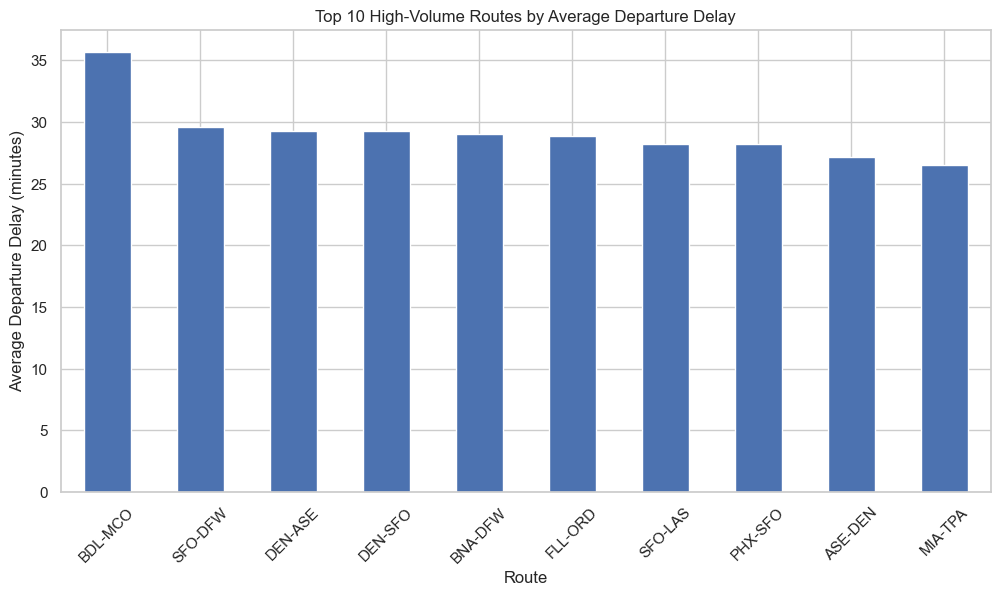

In [48]:
plt.figure(figsize=(12, 6))
route_dep_delay_filtered.plot(kind="bar")
plt.title("Top 10 High-Volume Routes by Average Departure Delay")
plt.xlabel("Route")
plt.ylabel("Average Departure Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

### Highest Average Departure Delay Among High-Volume Routes

After filtering out low-volume routes, I visualize the routes with the highest average departure delay. This provides a more reliable view of operationally stressed routes.

In [47]:
route_dep_delay_filtered = (
    df_filtered.groupby("ROUTE")["DEP_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

route_dep_delay_filtered

ROUTE
BDL-MCO    35.666667
SFO-DFW    29.607261
DEN-ASE    29.277267
DEN-SFO    29.254918
BNA-DFW    29.025271
FLL-ORD    28.853982
SFO-LAS    28.240584
PHX-SFO    28.193412
ASE-DEN    27.135593
MIA-TPA    26.549921
Name: DEP_DELAY, dtype: float64

In [46]:
# Count number of flights per route
route_counts = df_clean["ROUTE"].value_counts()

# Keep only routes with at least 500 flights
valid_routes = route_counts[route_counts >= 500].index

df_filtered = df_clean[df_clean["ROUTE"].isin(valid_routes)]

### Filtering Routes with Low Flight Volume

Some routes show very high average delays, but this can be misleading if the number of flights is very small.

To ensure more reliable insights, I filter routes with a minimum number of flights before analyzing average delays.

In [45]:
route_dep_delay = (
    df_clean.groupby("ROUTE")["DEP_DELAY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

route_dep_delay

ROUTE
DFW-STT    213.076923
STT-DFW    154.400000
BGR-FLL    151.714286
BLV-FLL    125.923077
DAL-PBI    118.000000
MYR-ABE    116.961538
PBI-MDW    115.750000
XNA-FLL    112.615385
HDN-BOS    112.187500
AUS-TYS    111.909091
Name: DEP_DELAY, dtype: float64

### Route-Level Average Departure Delay

After identifying the busiest routes, I calculate the average departure delay by route. This helps highlight which routes experience more operational disruption on average.

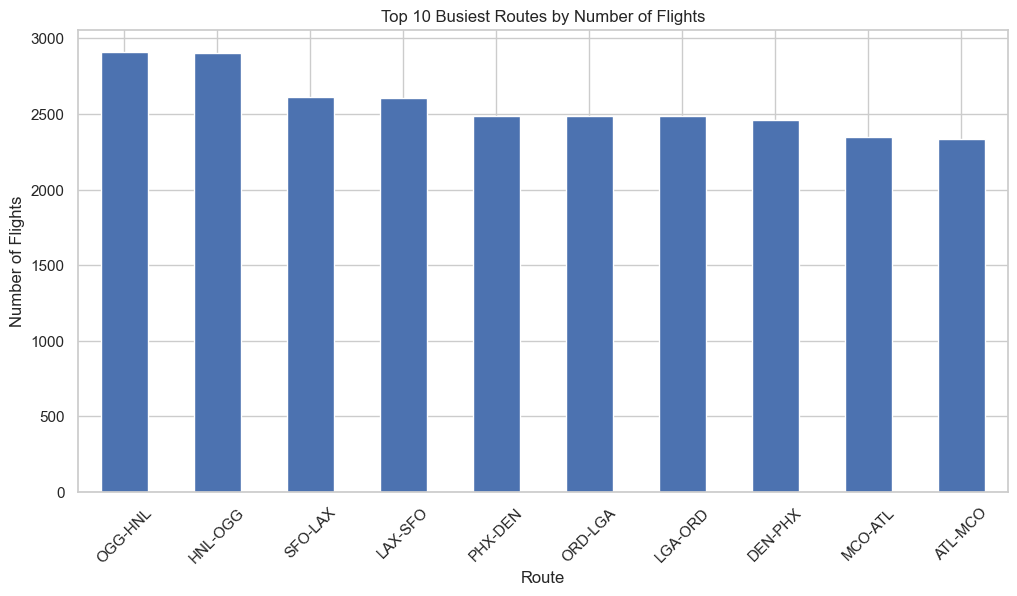

In [44]:
plt.figure(figsize=(12, 6))
top_routes.plot(kind="bar")
plt.title("Top 10 Busiest Routes by Number of Flights")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

### Visualizing the Busiest Routes

I visualize the top 10 busiest routes to better understand which airport pairs account for the highest concentration of flights in the dataset.

In [43]:
top_routes = df_clean["ROUTE"].value_counts().head(10)
top_routes

ROUTE
OGG-HNL    2910
HNL-OGG    2903
SFO-LAX    2610
LAX-SFO    2607
PHX-DEN    2490
ORD-LGA    2490
LGA-ORD    2489
DEN-PHX    2459
MCO-ATL    2345
ATL-MCO    2338
Name: count, dtype: int64

### Identifying the Busiest Routes

To understand where flight activity is concentrated, I identify the busiest routes in the dataset based on the number of flights. This helps establish which airport pairs dominate operations and may deserve closer revenue and delay analysis later.

In [42]:
df_clean[["ORIGIN", "DEST", "ROUTE"]].head()

,ORIGIN,DEST,ROUTE
0,ATL,AVL,ATL-AVL
1,DTW,OMA,DTW-OMA
2,DSM,DTW,DSM-DTW
3,LGA,SAV,LGA-SAV
4,CHS,LGA,CHS-LGA


In [41]:
df_clean["ROUTE"] = df_clean["ORIGIN"] + "-" + df_clean["DEST"]

### Creating a Route Identifier

To analyze operational performance at the route level, I create a route variable by combining the origin and destination airport codes. This makes it easier to group flights by airport pair and compare route-level behavior.

### Observation

- Arrival delays are generally lower than departure delays
- This suggests that flights are able to recover some delays during the journey
- However, extreme delays still persist, indicating operational inefficiencies in certain cases

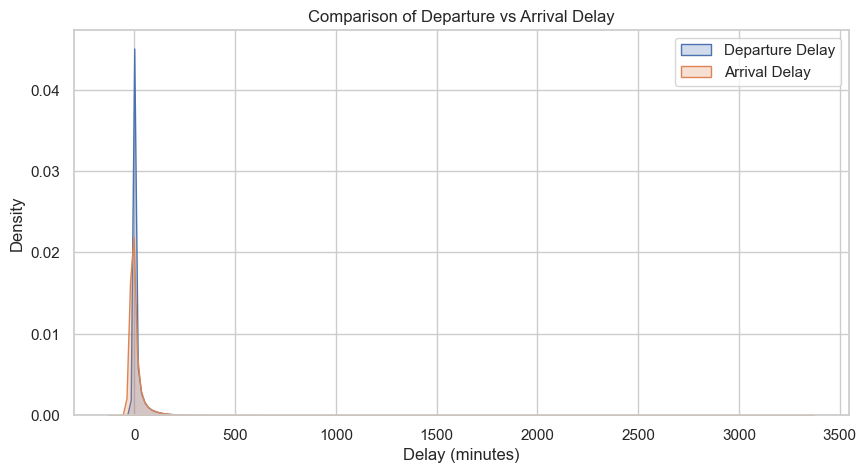

In [40]:
plt.figure(figsize=(10, 5))

sns.kdeplot(df_clean["DEP_DELAY"], label="Departure Delay", fill=True)
sns.kdeplot(df_clean["ARR_DELAY"], label="Arrival Delay", fill=True)

plt.title("Comparison of Departure vs Arrival Delay")
plt.xlabel("Delay (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()

### Comparing Departure and Arrival Delays

To better understand how delays evolve during a flight, I compare the distributions of departure and arrival delays side by side.

### Interpretation of Arrival Delay Statistics

- The average arrival delay is approximately 5.8 minutes, which is lower than the average departure delay.
- The median arrival delay is -6 minutes, indicating that most flights arrive slightly early.
- Similar to departure delays, the distribution is right-skewed with extreme outliers (maximum delay over 3000 minutes).
- The interquartile range (-16 to 8 minutes) suggests that the majority of flights arrive within a reasonable time window.
- The lower mean compared to departure delay suggests that flights may recover some delay during transit.

In [39]:
df_clean["ARR_DELAY"].describe()

count    1.654563e+06
mean     5.773356e+00
std      5.800592e+01
min     -1.170000e+02
25%     -1.600000e+01
50%     -6.000000e+00
75%      8.000000e+00
max      3.359000e+03
Name: ARR_DELAY, dtype: float64

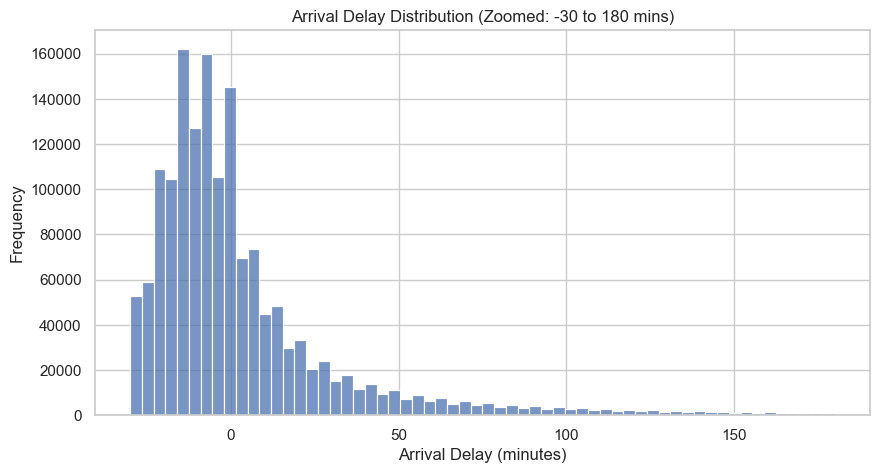

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean["ARR_DELAY"].between(-30, 180)]["ARR_DELAY"], bins=60)
plt.title("Arrival Delay Distribution (Zoomed: -30 to 180 mins)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

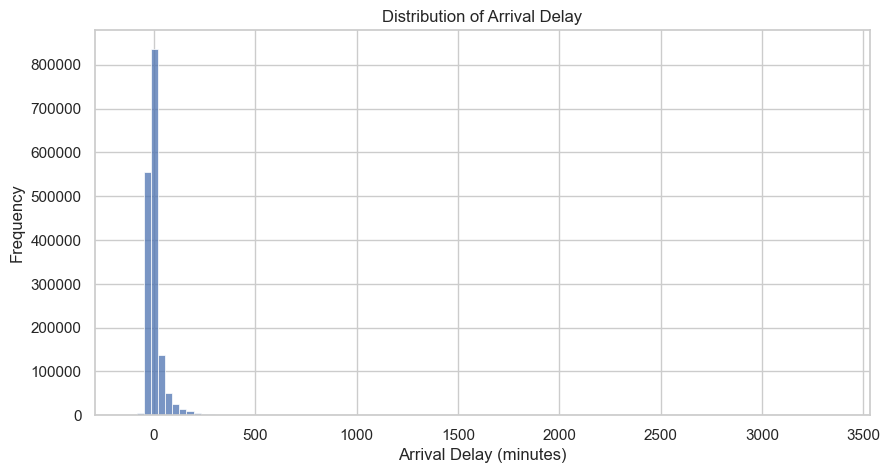

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["ARR_DELAY"], bins=100)
plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

### Distribution of Arrival Delay

Next, I analyze the distribution of arrival delays to understand how delays propagate through flight operations and whether arrival performance differs from departure performance.

### Interpretation of Departure Delay Statistics

- The average departure delay is approximately 11.6 minutes, indicating that flights are slightly delayed on average.
- The median delay is -2 minutes, meaning that at least half of the flights depart on time or slightly early.
- The difference between the mean and median suggests that the distribution is right-skewed, with a small number of flights experiencing very large delays.
- The presence of extreme values (maximum delay of over 3000 minutes) indicates significant outliers.
- The interquartile range (-6 to 8 minutes) shows that most flights are relatively close to on-time performance.

These observations confirm that the delay distribution is not normal and is influenced by extreme values, which will be important when selecting appropriate statistical methods later.

In [36]:
df_clean["DEP_DELAY"].describe()

count    1.654563e+06
mean     1.162407e+01
std      5.543050e+01
min     -9.600000e+01
25%     -6.000000e+00
50%     -2.000000e+00
75%      8.000000e+00
max      3.360000e+03
Name: DEP_DELAY, dtype: float64

### Descriptive Statistics for Departure Delay

To complement the visual distribution, I calculate summary statistics for departure delay. This helps quantify the center, spread, and extreme values in the data.

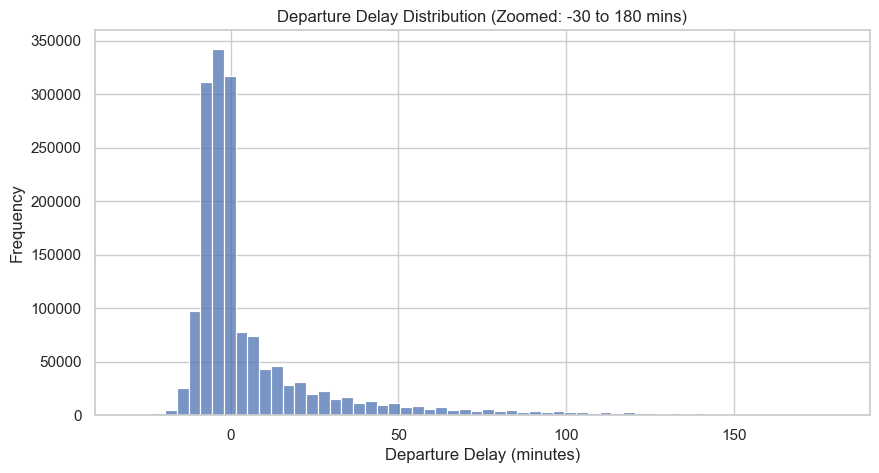

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean["DEP_DELAY"].between(-30, 180)]["DEP_DELAY"], bins=60)
plt.title("Departure Delay Distribution (Zoomed: -30 to 180 mins)")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

### Zoomed View of Departure Delay

Because a small number of flights experience very large delays, the full distribution can be heavily skewed. To better understand the main pattern, I create a zoomed view that focuses on a practical range of departure delays.

### Initial Observation

This chart helps show whether departure delays are concentrated around zero or spread across a wider range. It also helps identify whether the variable is normally distributed or skewed, which will matter later for statistical testing and modeling.

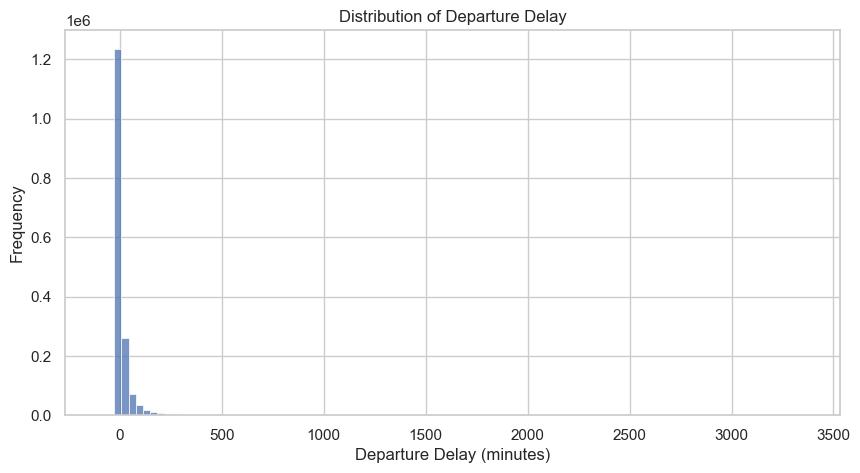

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["DEP_DELAY"], bins=100)
plt.title("Distribution of Departure Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

## Exploratory Data Analysis (EDA)

In this section, I explore the cleaned dataset to understand patterns, distributions, and operational behavior across flights.

I begin by analyzing the distribution of departure delays to understand whether delays are centered around on-time performance or influenced by a smaller number of heavily delayed flights.

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [32]:
%pip install matplotlib seaborn

68927.10s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Exploratory Data Analysis (EDA)

In this section, I explore the cleaned dataset to understand patterns, distributions, and relationships between key variables such as delays, routes, and operational performance.

I begin by analyzing the distribution of departure and arrival delays.

## Data Cleaning Summary

The following data cleaning steps were performed to prepare the dataset for analysis:

- Selected relevant columns from the raw dataset to focus on operational and route-level features
- Combined monthly datasets (January–March 2024) into a single dataset
- Identified missing values and analyzed their patterns
- Filled missing delay values (DEP_DELAY, ARR_DELAY) for cancelled flights with 0, based on business logic
- Investigated remaining missing values and identified diverted flights as the cause
- Excluded diverted flights to ensure consistency in delay-based analysis
- Verified that no missing values remain in key numerical columns
- Saved the cleaned dataset for further analysis

This cleaned dataset will be used for exploratory data analysis, statistical testing, and modeling.

In [30]:
df_clean.to_csv("../data/processed/on_time_q1_2024_cleaned.csv", index=False)

### Saving Final Cleaned Dataset

After handling missing values and excluding diverted flights, we save the cleaned dataset for further analysis. This ensures that all downstream steps use a consistent and validated dataset.

In [29]:
df_clean.shape

(1654563, 10)

### Verifying Dataset Size After Cleaning

After excluding diverted flights, checking the dataset dimensions again to understand how many records remain for further analysis.

In [28]:
df_clean[["DEP_DELAY", "ARR_DELAY"]].isnull().sum()

DEP_DELAY    0
ARR_DELAY    0
dtype: int64

In [27]:
df_clean = df_clean[df_clean["DIVERTED"] == 0].copy()

### Excluding Diverted Flights

A small number of flights still have missing `ARR_DELAY` values because they were diverted. Since diverted flights do not follow the standard arrival process, they can distort delay-based analysis.

To keep the analysis focused and interpretable, diverted flights are excluded from the cleaned working dataset.

In [26]:
df_clean[df_clean["ARR_DELAY"].isnull()][["CANCELLED", "DIVERTED"]].value_counts()

CANCELLED  DIVERTED
0.0        1.0         3696
Name: count, dtype: int64

### Investigating Remaining Missing Arrival Delays

After filling missing delay values for cancelled flights, a small number of `ARR_DELAY` values are still missing. These are likely related to diverted flights or incomplete arrival records, so I inspect them before making any further cleaning decisions.

In [25]:
df_clean[["DEP_DELAY", "ARR_DELAY"]].isnull().sum()

DEP_DELAY       0
ARR_DELAY    3696
dtype: int64

In [24]:
# Fill missing delays for cancelled flights
df_clean.loc[df_clean["CANCELLED"] == 1, "DEP_DELAY"] = 0
df_clean.loc[df_clean["CANCELLED"] == 1, "ARR_DELAY"] = 0

### Handling Missing Delay Values for Cancelled Flights

Delay values (DEP_DELAY and ARR_DELAY) are missing for cancelled flights because the flight never occurred.

To maintain consistency in the dataset and allow for numerical analysis, I replace missing delay values with 0 for cancelled flights.

### Understanding Flight Cancellation Volume

Before handling missing delay values, first I examine the number of cancelled flights in the dataset. This helps confirm how much of the missing delay information is explained by flight cancellations.

In [23]:
df_clean["CANCELLED"].value_counts()

CANCELLED
0.0    1629748
1.0      28511
Name: count, dtype: int64

### Verifying Data Copy

Connfirming that the copied dataset has the same dimensions as the original dataset before applying any cleaning operations.

In [22]:
df_clean.shape

(1658259, 10)

### Creating a Working Copy

To ensure reproducibility and avoid modifying the original dataset, I created a copy of the combined dataset. All cleaning and transformations will be applied to this copy.

In [21]:
df_clean = df_all.copy()

## Data Cleaning – Handling Missing Values

In this dataset, missing values are not random and are driven by business logic.

- Delay values (DEP_DELAY, ARR_DELAY) are missing primarily for cancelled flights.
- Cancellation codes are only present when a flight is cancelled.

To preserve the integrity of the analysis, I create a cleaned copy of the dataset and handle missing values carefully instead of applying generic imputation.

In [20]:
df_all[df_all["ARR_DELAY"].isnull()]["CANCELLED"].value_counts()

CANCELLED
1.0    28511
0.0     3696
Name: count, dtype: int64

In [ ]:
#checking whether missing delays are mostly from cancelled flights
df_all[df_all["DEP_DELAY"].isnull()]["CANCELLED"].value_counts()\

CANCELLED
1.0    27679
Name: count, dtype: int64

In [18]:
df_all["CANCELLED"].value_counts()

CANCELLED
0.0    1629748
1.0      28511
Name: count, dtype: int64

In [17]:
df_all.isnull().sum()

FL_DATE                    0
OP_UNIQUE_CARRIER          0
ORIGIN                     0
DEST                       0
DEP_DELAY              27679
ARR_DELAY              32207
CANCELLED                  0
CANCELLATION_CODE    1629748
DIVERTED                   0
DISTANCE                   0
dtype: int64

## Project Objective

The goal of this analysis is to identify routes with operational inefficiencies, such as high delays and cancellation rates, which may contribute to revenue leakage and poor service performance.

By analyzing flight-level data and aggregating it at the route level, this project aims to uncover patterns in operational disruption and highlight routes that may require intervention.

In [16]:
df_all.shape

(1658259, 10)

In [15]:
df_all.head()

,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,DISTANCE
0,1/1/2024 12:00:00 AM,9E,ATL,AVL,-4.0,-17.0,0.0,NaN,0.0,164.0
1,1/1/2024 12:00:00 AM,9E,DTW,OMA,-4.0,-33.0,0.0,NaN,0.0,651.0
2,1/1/2024 12:00:00 AM,9E,DSM,DTW,-5.0,-8.0,0.0,NaN,0.0,533.0
3,1/1/2024 12:00:00 AM,9E,LGA,SAV,-5.0,-26.0,0.0,NaN,0.0,722.0
4,1/1/2024 12:00:00 AM,9E,CHS,LGA,-7.0,-21.0,0.0,NaN,0.0,641.0


In [14]:
df_all.to_csv("../data/processed/on_time_q1_2024.csv", index=False)

In [13]:
import pandas as pd

# Load all 3 months
df_jan = pd.read_csv("../data/raw/on_time/on_time_2024_01.csv")
df_feb = pd.read_csv("../data/raw/on_time/on_time_2024_02.csv")
df_mar = pd.read_csv("../data/raw/on_time/on_time_2024_03.csv")

# Keep only needed columns
columns_needed = [
    "FL_DATE",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_DELAY",
    "ARR_DELAY",
    "CANCELLED",
    "CANCELLATION_CODE",
    "DIVERTED",
    "DISTANCE"
]

df_jan = df_jan[columns_needed]
df_feb = df_feb[columns_needed]
df_mar = df_mar[columns_needed]

# Combine all months
df_all = pd.concat([df_jan, df_feb, df_mar], ignore_index=True)

# Check result
df_all.shape

/var/folders/qb/9bsn8dl942bbdrp67pvjggd40000gn/T/ipykernel_91701/2823691522.py:4: DtypeWarning: Columns (0: DIV2_AIRPORT, 1: DIV2_TAIL_NUM, 2: DIV3_AIRPORT, 3: DIV3_TAIL_NUM) have mixed types. Specify dtype option on import or set low_memory=False.
  df_jan = pd.read_csv("../data/raw/on_time/on_time_2024_01.csv")
/var/folders/qb/9bsn8dl942bbdrp67pvjggd40000gn/T/ipykernel_91701/2823691522.py:5: DtypeWarning: Columns (0: DIV2_AIRPORT, 1: DIV2_TAIL_NUM) have mixed types. Specify dtype option on import or set low_memory=False.
  df_feb = pd.read_csv("../data/raw/on_time/on_time_2024_02.csv")
/var/folders/qb/9bsn8dl942bbdrp67pvjggd40000gn/T/ipykernel_91701/2823691522.py:6: DtypeWarning: Columns (0: DIV1_TAIL_NUM, 1: DIV2_AIRPORT, 2: DIV2_TAIL_NUM) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mar = pd.read_csv("../data/raw/on_time/on_time_2024_03.csv")


(1658259, 10)

In [12]:
df.to_csv("../data/processed/on_time_2024_01_cleaned.csv",index=False)

In [10]:
df.shape

(547271, 10)

In [9]:
columns_needed = [
    "FL_DATE",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_DELAY",
    "ARR_DELAY",
    "CANCELLED",
    "CANCELLATION_CODE",
    "DIVERTED",
    "DISTANCE"
]

df = df[columns_needed]
df.head()

,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,DISTANCE
0,1/1/2024 12:00:00 AM,9E,ATL,AVL,-4.0,-17.0,0.0,NaN,0.0,164.0
1,1/1/2024 12:00:00 AM,9E,DTW,OMA,-4.0,-33.0,0.0,NaN,0.0,651.0
2,1/1/2024 12:00:00 AM,9E,DSM,DTW,-5.0,-8.0,0.0,NaN,0.0,533.0
3,1/1/2024 12:00:00 AM,9E,LGA,SAV,-5.0,-26.0,0.0,NaN,0.0,722.0
4,1/1/2024 12:00:00 AM,9E,CHS,LGA,-7.0,-21.0,0.0,NaN,0.0,641.0


In [ ]:
set(columns_needed) - set(df.columns)#to check if all columns are present

In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 547271 entries, 0 to 547270
Columns: 109 entries, YEAR to DIV5_TAIL_NUM
dtypes: float64(67), int64(21), str(21)
memory usage: 455.1 MB


In [ ]:
import pandas as pd 
df = pd.read_csv("../data/raw/on_time/on_time_2024_01.csv")
df.head()
df.columns.tolist()


/var/folders/qb/9bsn8dl942bbdrp67pvjggd40000gn/T/ipykernel_91701/3361011739.py:2: DtypeWarning: Columns (0: DIV2_AIRPORT, 1: DIV2_TAIL_NUM, 2: DIV3_AIRPORT, 3: DIV3_TAIL_NUM) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/on_time/on_time_2024_01.csv")


['YEAR',
 'QUARTER',
 'MONTH',
 'DAY_OF_MONTH',
 'DAY_OF_WEEK',
 'FL_DATE',
 'OP_UNIQUE_CARRIER',
 'OP_CARRIER_AIRLINE_ID',
 'OP_CARRIER',
 'TAIL_NUM',
 'OP_CARRIER_FL_NUM',
 'ORIGIN_AIRPORT_ID',
 'ORIGIN_AIRPORT_SEQ_ID',
 'ORIGIN_CITY_MARKET_ID',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_ABR',
 'ORIGIN_STATE_FIPS',
 'ORIGIN_STATE_NM',
 'ORIGIN_WAC',
 'DEST_AIRPORT_ID',
 'DEST_AIRPORT_SEQ_ID',
 'DEST_CITY_MARKET_ID',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_ABR',
 'DEST_STATE_FIPS',
 'DEST_STATE_NM',
 'DEST_WAC',
 'CRS_DEP_TIME',
 'DEP_TIME',
 'DEP_DELAY',
 'DEP_DELAY_NEW',
 'DEP_DEL15',
 'DEP_DELAY_GROUP',
 'DEP_TIME_BLK',
 'TAXI_OUT',
 'WHEELS_OFF',
 'WHEELS_ON',
 'TAXI_IN',
 'CRS_ARR_TIME',
 'ARR_TIME',
 'ARR_DELAY',
 'ARR_DELAY_NEW',
 'ARR_DEL15',
 'ARR_DELAY_GROUP',
 'ARR_TIME_BLK',
 'CANCELLED',
 'CANCELLATION_CODE',
 'DIVERTED',
 'CRS_ELAPSED_TIME',
 'ACTUAL_ELAPSED_TIME',
 'AIR_TIME',
 'FLIGHTS',
 'DISTANCE',
 'DISTANCE_GROUP',
 'CARRIER_DELAY',
 'WEATHER_DELAY',
 'NAS_DEL